In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("messy.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   OrderID   30 non-null     int64  
 1   Category  30 non-null     object 
 2   Region    30 non-null     object 
 3   Sales     28 non-null     float64
 4   Profit    29 non-null     float64
 5   Discount  28 non-null     float64
 6   Quantity  29 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 1.8+ KB


,OrderID,Sales,Profit,Discount,Quantity
count,30.000000,28.000000,29.000000,28.000000,29.000000
mean,15.500000,1848.214286,194.896552,0.125000,3.586207
std,8.803408,1595.909246,249.902030,0.099536,1.803117
min,1.000000,150.000000,-100.000000,0.000000,1.000000
25%,8.250000,387.500000,22.000000,0.050000,2.000000
50%,15.500000,1275.000000,60.000000,0.100000,3.000000
75%,22.750000,3125.000000,380.000000,0.200000,5.000000
max,30.000000,5200.000000,720.000000,0.300000,7.000000


In [24]:
df.isnull().sum()
df = df.drop_duplicates()
df

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
0,1,Technology,West,2500.0,300.0,0.10,5.0
1,2,Furniture,East,1800.0,200.0,0.20,3.0
2,3,Office Supplies,South,300.0,50.0,NaN,2.0
3,4,Technology,North,4000.0,500.0,0.15,6.0
4,5,Furniture,West,1200.0,-100.0,0.30,4.0
5,6,Office Supplies,East,150.0,20.0,0.05,1.0
6,7,Technology,South,3200.0,400.0,0.10,5.0
7,8,Furniture,North,800.0,-50.0,0.25,2.0
8,9,Office Supplies,West,200.0,30.0,0.00,3.0
9,10,Technology,East,5000.0,700.0,0.05,7.0


In [33]:
s = df['Sales'].mean()
df['Sales'].fillna(s,inplace=True)
df['Profit'].fillna(0,inplace=True)
df['Discount'].fillna(0,inplace=True)
df['Quantity'].fillna(0,inplace=True)


/tmp/ipykernel_366/3171159011.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(s,inplace=True)
/tmp/ipykernel_366/3171159011.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method

In [34]:
df.dtypes
df

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
0,1,Technology,West,2500.000000,300.0,0.10,5.0
1,2,Furniture,East,1800.000000,200.0,0.20,3.0
2,3,Office Supplies,South,300.000000,50.0,0.00,2.0
3,4,Technology,North,4000.000000,500.0,0.15,6.0
4,5,Furniture,West,1200.000000,-100.0,0.30,4.0
5,6,Office Supplies,East,150.000000,20.0,0.05,1.0
6,7,Technology,South,3200.000000,400.0,0.10,5.0
7,8,Furniture,North,800.000000,-50.0,0.25,2.0
8,9,Office Supplies,West,200.000000,30.0,0.00,3.0
9,10,Technology,East,5000.000000,700.0,0.05,7.0


In [27]:
df.groupby("Category")["Sales"].sum()
df[df["Profit"] < 0]

,OrderID,Category,Region,Sales,Profit,Discount,Quantity
4,5,Furniture,West,1200.0,-100.0,0.30,4.0
7,8,Furniture,North,800.0,-50.0,0.25,2.0
16,17,Furniture,West,1300.0,-80.0,0.30,4.0
19,20,Furniture,North,900.0,-60.0,0.25,2.0
24,25,Furniture,West,1250.0,-90.0,0.30,NaN
27,28,Furniture,North,850.0,-55.0,0.25,2.0


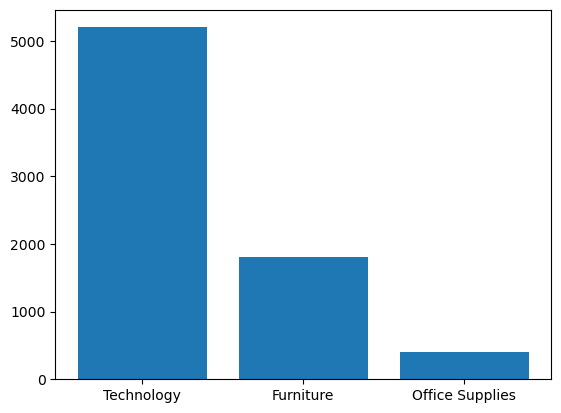

In [28]:
# Bar chart
df.groupby("Category")["Sales"].sum()
plt.bar(df['Category'],df['Sales'])
plt.show()



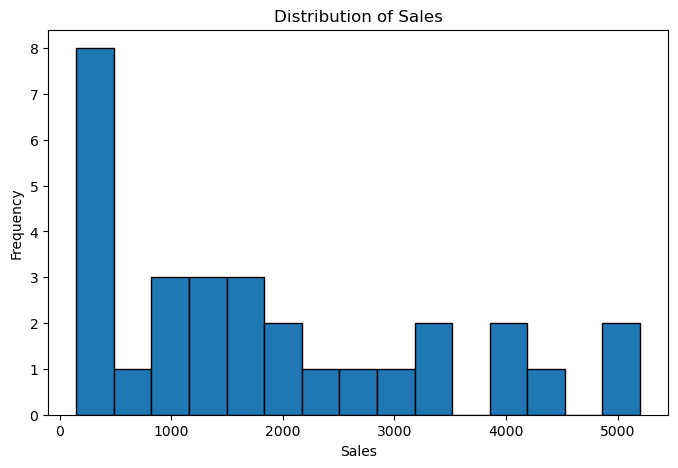

In [37]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=15, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#OBSERVATIONS
#1.The Technology category has the highest sales compared to other categories.
#2.Higher discounts tend to reduce profit and sometimes lead to losses.
#3.The Furniture category shows several cases of negative profit, indicating losses.
#4.The dataset had missing values, which were removed before performing the analysis.
#5.Most sales values are low, with only a few high-value transactions.